In [32]:
# 入力データの取得

from pathlib import Path
import os

print(os.getcwd())

ALL_DATA = sorted(Path("./input").iterdir())
ARTICLE_PATH, CUSTOMERS_PATH, SAMPLE_SUBMISSION_PATH, TRANSAC_PATH = ALL_DATA

/Users/kurokawa/Desktop/hobby/data_analysis/kaggle/h_and_m


In [35]:
import polars as pl

articles_df = pl.read_csv(ARTICLE_PATH)  # (105_542, 25)
custom_df = pl.read_csv(CUSTOMERS_PATH)  # (105_542, 25)
sample_sub_df = pl.read_csv(SAMPLE_SUBMISSION_PATH)  # (1, 7)
transac_df = pl.read_csv(TRANSAC_PATH)  # このデータが重いから注意(31_788_324, 5)

In [12]:
# 取引データ
print(transac_df.schema)
print(transac_df.null_count())
transac_df.head()

Schema({'t_dat': String, 'customer_id': String, 'article_id': Int64, 'price': Float64, 'sales_channel_id': Int64})
shape: (1, 5)
┌───────┬─────────────┬────────────┬───────┬──────────────────┐
│ t_dat ┆ customer_id ┆ article_id ┆ price ┆ sales_channel_id │
│ ---   ┆ ---         ┆ ---        ┆ ---   ┆ ---              │
│ u32   ┆ u32         ┆ u32        ┆ u32   ┆ u32              │
╞═══════╪═════════════╪════════════╪═══════╪══════════════════╡
│ 0     ┆ 0           ┆ 0          ┆ 0     ┆ 0                │
└───────┴─────────────┴────────────┴───────┴──────────────────┘


t_dat,customer_id,article_id,price,sales_channel_id
str,str,i64,f64,i64
"""2018-09-20""","""000058a12d5b43e67d225668fa1f8d…",663713001,0.050831,2
"""2018-09-20""","""000058a12d5b43e67d225668fa1f8d…",541518023,0.030492,2
"""2018-09-20""","""00007d2de826758b65a93dd24ce629…",505221004,0.015237,2
"""2018-09-20""","""00007d2de826758b65a93dd24ce629…",685687003,0.016932,2
"""2018-09-20""","""00007d2de826758b65a93dd24ce629…",685687004,0.016932,2


In [16]:
# 商品データ
pl.Config.set_tbl_cols(-1)

print(articles_df.schema)
print(articles_df.null_count())
articles_df.head()

Schema({'article_id': Int64, 'product_code': Int64, 'prod_name': String, 'product_type_no': Int64, 'product_type_name': String, 'product_group_name': String, 'graphical_appearance_no': Int64, 'graphical_appearance_name': String, 'colour_group_code': Int64, 'colour_group_name': String, 'perceived_colour_value_id': Int64, 'perceived_colour_value_name': String, 'perceived_colour_master_id': Int64, 'perceived_colour_master_name': String, 'department_no': Int64, 'department_name': String, 'index_code': String, 'index_name': String, 'index_group_no': Int64, 'index_group_name': String, 'section_no': Int64, 'section_name': String, 'garment_group_no': Int64, 'garment_group_name': String, 'detail_desc': String})
shape: (1, 25)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ art ┆ pro ┆ pro ┆ pro ┆ pro ┆ pro ┆ gra ┆ gra ┆ col ┆ col ┆ per ┆ per ┆ per ┆ per ┆ dep ┆ dep ┆ ind ┆ ind ┆ ind ┆ ind ┆

article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
i64,i64,str,i64,str,str,i64,str,i64,str,i64,str,i64,str,i64,str,str,str,i64,str,i64,str,i64,str,str
108775015,108775,"""Strap top""",253,"""Vest top""","""Garment Upper body""",1010016,"""Solid""",9,"""Black""",4,"""Dark""",5,"""Black""",1676,"""Jersey Basic""","""A""","""Ladieswear""",1,"""Ladieswear""",16,"""Womens Everyday Basics""",1002,"""Jersey Basic""","""Jersey top with narrow shoulde…"
108775044,108775,"""Strap top""",253,"""Vest top""","""Garment Upper body""",1010016,"""Solid""",10,"""White""",3,"""Light""",9,"""White""",1676,"""Jersey Basic""","""A""","""Ladieswear""",1,"""Ladieswear""",16,"""Womens Everyday Basics""",1002,"""Jersey Basic""","""Jersey top with narrow shoulde…"
108775051,108775,"""Strap top (1)""",253,"""Vest top""","""Garment Upper body""",1010017,"""Stripe""",11,"""Off White""",1,"""Dusty Light""",9,"""White""",1676,"""Jersey Basic""","""A""","""Ladieswear""",1,"""Ladieswear""",16,"""Womens Everyday Basics""",1002,"""Jersey Basic""","""Jersey top with narrow shoulde…"
110065001,110065,"""OP T-shirt (Idro)""",306,"""Bra""","""Underwear""",1010016,"""Solid""",9,"""Black""",4,"""Dark""",5,"""Black""",1339,"""Clean Lingerie""","""B""","""Lingeries/Tights""",1,"""Ladieswear""",61,"""Womens Lingerie""",1017,"""Under-, Nightwear""","""Microfibre T-shirt bra with un…"
110065002,110065,"""OP T-shirt (Idro)""",306,"""Bra""","""Underwear""",1010016,"""Solid""",10,"""White""",3,"""Light""",9,"""White""",1339,"""Clean Lingerie""","""B""","""Lingeries/Tights""",1,"""Ladieswear""",61,"""Womens Lingerie""",1017,"""Under-, Nightwear""","""Microfibre T-shirt bra with un…"


In [30]:
# 購入者データ
print(custom_df.schema)
print(custom_df.null_count())
custom_df.head()
print(len(custom_df))

Schema({'customer_id': String, 'FN': Float64, 'Active': Float64, 'club_member_status': String, 'fashion_news_frequency': String, 'age': Int64, 'postal_code': String})
shape: (1, 7)
┌─────────────┬────────┬────────┬────────────────────┬────────────────────────┬───────┬─────────────┐
│ customer_id ┆ FN     ┆ Active ┆ club_member_status ┆ fashion_news_frequency ┆ age   ┆ postal_code │
│ ---         ┆ ---    ┆ ---    ┆ ---                ┆ ---                    ┆ ---   ┆ ---         │
│ u32         ┆ u32    ┆ u32    ┆ u32                ┆ u32                    ┆ u32   ┆ u32         │
╞═════════════╪════════╪════════╪════════════════════╪════════════════════════╪═══════╪═════════════╡
│ 0           ┆ 895050 ┆ 907576 ┆ 6062               ┆ 16009                  ┆ 15861 ┆ 0           │
└─────────────┴────────┴────────┴────────────────────┴────────────────────────┴───────┴─────────────┘
1371980


In [17]:
# 提出データ
print(sample_sub_df.schema)
sample_sub_df.head()

Schema({'customer_id': String, 'prediction': String})


customer_id,prediction
str,str
"""00000dbacae5abe5e23885899a1fa4…","""0706016001 0706016002 03728600…"
"""0000423b00ade91418cceaf3b26c6a…","""0706016001 0706016002 03728600…"
"""000058a12d5b43e67d225668fa1f8d…","""0706016001 0706016002 03728600…"
"""00005ca1c9ed5f5146b52ac8639a40…","""0706016001 0706016002 03728600…"
"""00006413d8573cd20ed7128e53b7b1…","""0706016001 0706016002 03728600…"


In [24]:
pl.Config.set_fmt_str_lengths(100000)

print(sample_sub_df.head(1)["prediction"])

shape: (1,)
Series: 'prediction' [str]
[
	"0706016001 0706016002 0372860001 0610776002 0759871002 0464297007 0372860002 0610776001 0399223001 0706016003 0720125001 0156231001"
]


In [28]:
contents = sample_sub_df.head(1)["prediction"].item()

print(len(contents.split()))
print(sample_sub_df.head(1)["prediction"].item())

12
0706016001 0706016002 0372860001 0610776002 0759871002 0464297007 0372860002 0610776001 0399223001 0706016003 0720125001 0156231001


# article.csv に関する分析

pandas の import 時間: 0.27259111404418945second


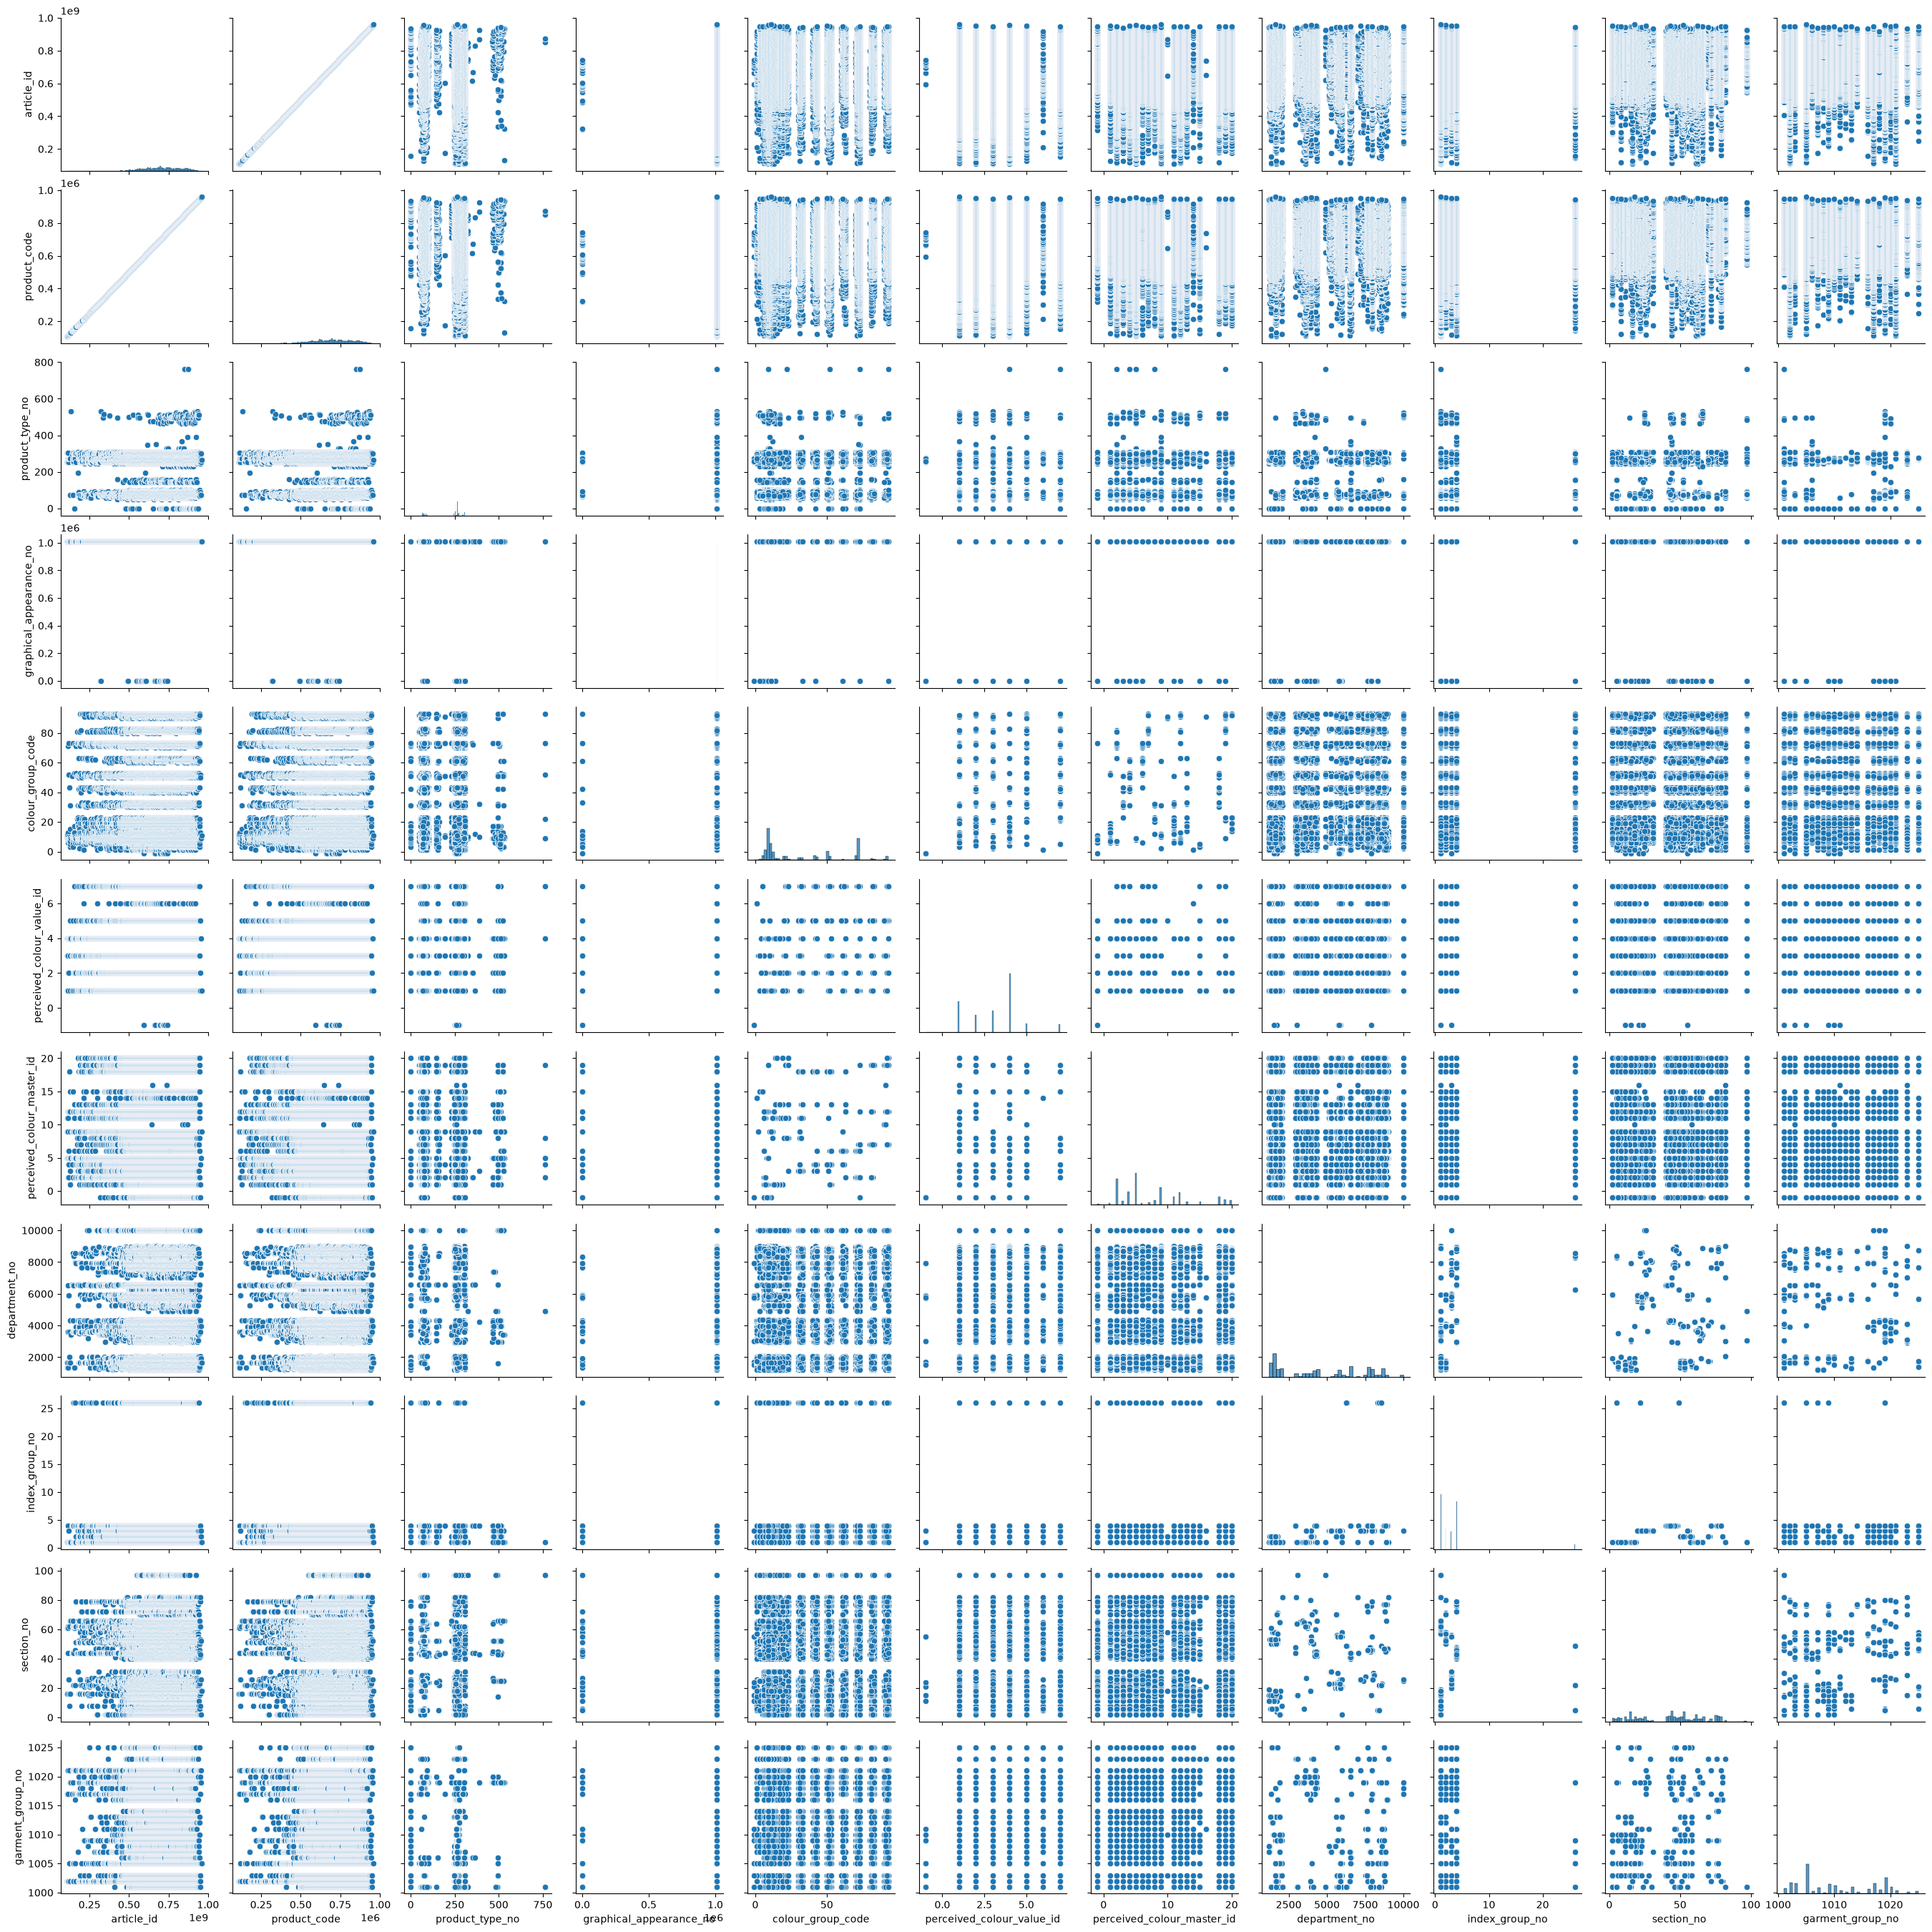

In [33]:
import pandas as pd
import seaborn as sns
import time

start = time.time()
articles_df = pd.read_csv(ARTICLE_PATH)
end = time.time()
diff = end - start
print(f"pandas の import 時間: {diff}second")

sns.pairplot(articles_df)

In [ ]:
# 商品の分類の関係性に関して

# 全商品の数(色違いとサイズ違いでも同じコード)
# print(f"全商品の名称: {articles_df['product_code'].unique()}")  # 量が多いから省略
print(f"全商品の数: {len(articles_df['product_code'].unique())}")

################

# 商品の一般的なグループ名
print(f"商品の一般的なグループ名: {articles_df['department_name'].unique()}")  # fmt: skip
print(f"商品の一般的なグループ数: {len(articles_df['department_name'].unique())}")  # fmt: skip

################

# 商品のグループ(オンラインで使われてそうな分類名)（例："Young", "Ladieswear" など）
print(f"マーケティング上での全商品のグループ: {articles_df['index_name'].unique()}")
print(f"マーケティング上での全商品のグループ数: {len(articles_df['index_name'].unique())}")  # fmt: skip

# 商品のセクション（例："Kidswear", "Ladieswear", "Menswear"）
print(f"商品のセクション名: {articles_df['index_group_name'].unique()}")  # fmt: skip
print(f"商品のセクション数: {len(articles_df['index_group_name'].unique())}")  # fmt: skip

# 衣服のグループ（例："Womens Nightwear", "Mens Shirts" など）
print(f"衣服のグループ名: {articles_df['garment_group_name'].unique()}")  # fmt: skip
print(f"衣服のグループ数: {len(articles_df['garment_group_name'].unique())}")  # fmt: skip


#################

# 製品の大きなグループ名（例："Dress"、"Trousers" など）
print(f"全商品のグループ名: {articles_df['product_type_name'].unique()}")
print(f"全商品のグループ数: {len(articles_df['product_type_name'].unique())}")

#################

# 商品の見た目のパターン（例："Solid", "Striped", "All over pattern"）
print(f"商品の見た目のパターン名: {articles_df['graphical_appearance_name'].unique()}")
print(f"商品の見た目のパターン数: {len(articles_df['graphical_appearance_name'].unique())}")  # fmt: skip

# 商品の色グループ
print(f"商品の色のグループ名: {articles_df['colour_group_name'].unique()}")
print(f"商品の色のグループ数: {len(articles_df['colour_group_name'].unique())}")  # fmt: skip

# 商品の明るさグループ
print(f"商品の明るさグループ名: {articles_df['perceived_colour_value_name'].unique()}")
print(f"商品の明るさグループ数: {len(articles_df['perceived_colour_value_name'].unique())}")  # fmt: skip

# 商品の主観的な明るさグループ
print(f"商品の主観的な明るさグループ名: {articles_df['perceived_colour_master_name'].unique()}")  # fmt: skip
print(f"商品の主観的な明るさグループ数: {len(articles_df['perceived_colour_master_name'].unique())}")  # fmt: skip


全商品の数: 47224
全商品のグループ名: shape: (131,)
Series: 'product_type_name' [str]
[
	"Accessories set"
	"Cardigan"
	"Hair/alice band"
	"Wedge"
	"Leg warmers"
	"Braces"
	"Straw hat"
	"Vest top"
	"Sarong"
	"Earrings"
	"Gloves"
	"Fine cosmetics"
	"Jumpsuit/Playsuit"
	"Shorts"
	"Swimsuit"
	"Outdoor Waistcoat"
	"Trousers"
	"Flip flop"
	"Tote bag"
	"Necklace"
	"Bucket hat"
	"Leggings/Tights"
	"Hairband"
	"Other accessories"
	"Garment Set"
	"Bra"
	"Cross-body bag"
	"Felt hat"
	"Dress"
	"Blanket"
	"Jacket"
	"Outdoor overall"
	"Coat"
	"Dog Wear"
	"Swimwear bottom"
	"Bodysuit"
	"Soft Toys"
	"Heeled sandals"
	"Wood balls"
	"Pyjama set"
	"Earring"
	"Slippers"
	"Boots"
	"Ballerinas"
	"Waterbottle"
	"Sneakers"
	"Sleep Bag"
	"Unknown"
	"Toy"
	"Underwear Tights"
	"Wallet"
	"Pyjama jumpsuit/playsuit"
	"Side table"
	"Clothing mist"
	"Underwear body"
	"Scarf"
	"Cushion"
	"Towel"
	"Wireless earphone case"
	"Hat/brim"
	"Dog wear"
	"Alice band"
	"Beanie"
	"Sandals"
	"Night gown"
	"Top"
	"Backpack"
	"Giftbox"
	"Stain 

- カラムの関係性

```tree
カラムの関係性
└── 一般的なグループ名(department_name)
  └── 衣服のグループ？(index_name, index_group_name, garment_group_name)
    └── 衣服のグループ(product_type_name)
      └── マーケティング上での大分類(`index_name`)
        ├── 見た目のパターン(デザイン)(`graphical_appearance_name`)
        ├── 色(`colour_group_name`)
        ├── 商品の明るさ(`perceived_colour_value_name`)
        └── 主観的な明るさ(`perceived_colour_master_name`)
```

# customers.csv に関する分析

# transactions.csv に関する分析